# BUAD 405 · Applied Econometrics S'26
# Tutorial 4 — Cluster Analysis in Python

**Guided tutorial & Notebook**

### Learning objectives

By the end of this notebook, you should be able to:

1. Explain what **multivariate data analysis** is and why clustering is a multivariate method.
2. Explain what **cluster analysis** is trying to achieve.
3. Describe the basic logic of **K-means clustering**.
4. Explain why **standardization** matters for distance-based clustering.
5. Use an **elbow plot** and **silhouette score** to compare candidate values of K.
6. Fit K-means and interpret cluster profiles without treating cluster numbers as rankings.
7. Explain what a **dendrogram** shows in hierarchical clustering.
8. Communicate cluster findings cautiously and avoid causal or predictive claims that the analysis does not establish.

## 1. Multivariate Data Analysis

**Multivariate data analysis** is the broad study of datasets containing several variables measured for each observation.

For example, suppose each **country** has:

- GDP per capita
- Inflation
- Unemployment
- Internet use
- Education
- Life expectancy

Each row is one country, and each column is a different characteristic.

The key idea is that multivariate analysis examines these variables **together**, rather than studying each variable separately.

### Why does this matter for clustering?

Clustering looks at observations across **multiple characteristics simultaneously**. Instead of asking only:

> Which firms have high profitability?

we can ask:

> Which firms have similar combinations of profitability, leverage, working capital, liquidity, asset turnover, and size?

That is the basic setting in which cluster analysis becomes useful.

## 2. What can multivariate analysis be used for?

The lecture identifies several uses:

- **Explain or predict an outcome**
- **Identify underlying dimensions**
- **Reduce the number of variables**
- **Group similar observations**
- **Examine relationships among several variables**

Multivariate data analysis is therefore an **umbrella area**.

Two methods will be brought up in this Tutorial:

- **PCA (Principal Component Analysis)** — associated with identifying/reducing underlying dimensions. We will not go into details!
- **Cluster analysis** — used to group similar observations.

The term *multivariate* can sometimes be used narrowly to mean analyzing several outcome variables simultaneously. In this course, it is also used more broadly for analyses involving many variables.

# Part A — Cluster Analysis

## 3. What is cluster analysis?

**Cluster analysis is used to group observations so that observations within the same group are relatively similar, while observations in different groups are relatively dissimilar.**

The important point is that the algorithm forms the groups based on the variables supplied to it.

### Example:

Suppose we study countries using:

- unemployment
- inflation
- GDP per capita
- digital access

A clustering procedure might identify groups that, after examining their profiles, could be described as:

- high-income, digitally advanced economies;
- middle-income economies with moderate employment challenges;
- economies experiencing high inflation and unemployment.

**These labels are interpretations made after the algorithm forms the clusters.**

The algorithm does not automatically know that a cluster should be called “high-income digitally advanced economies.”

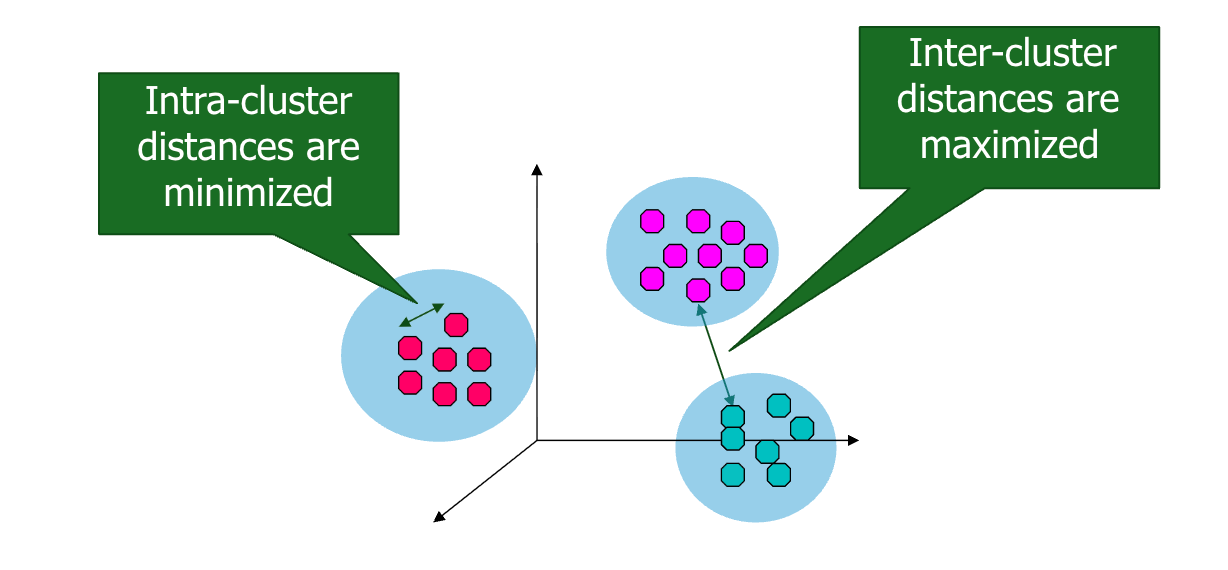

## 4. K-means clustering

A common clustering approach is **K-means**.

The researcher first selects the number of clusters, **K** (we'll discuss later how K is determined).

The basic algorithm is:

1. **Assign initial cluster centres.**
2. **Allocate each observation to the nearest centre.**
3. **Recalculate each cluster centre.**
4. **Repeat until the assignments stabilize.**

### Objective of K-means

K-means minimizes within-cluster variation:

$$
\min \sum_k \sum_{i \in C_k} \|x_i-\mu_k\|^2
$$

where:

- $C_k$ = cluster $k$
- $\mu_k$ = centre of cluster $k$
- $x_i$ = observation $i$

### Intuition

Think of each firm as a point in a multi-dimensional space.

K-means tries to place **K centres** so that firms assigned to the same centre are relatively close to that centre.

The resulting groups are therefore based on **distance/similarity** across the selected features.

## 5. Hierarchical clustering

**Hierarchical clustering builds a sequence of nested groups.**

In **agglomerative hierarchical clustering**:

1. Begin with every observation in its own cluster.
2. Gradually merge the most similar clusters.
3. Continue until the observations have been joined into a hierarchy.

The result can be displayed using a **dendrogram**.

### What does a dendrogram show?

A dendrogram shows **how observations or clusters are joined**.

The vertical height at which a merge occurs represents the merge distance under the chosen linkage method.

A large jump in merge height can provide evidence that a horizontal cut could be drawn before very dissimilar groups are forced together.

We will use **Ward linkage** in this tutorial but ther =e are other linkage methods.

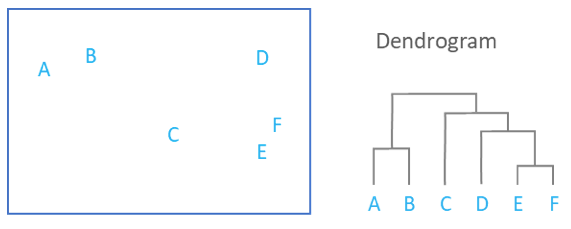

## 6. Why standardize before distance-based clustering?

Distance-based clustering is affected by the **scale of the variables**.

Imagine two features:

- GDP measured in thousands
- an institutional indicator ranging roughly from −2.5 to 2.5

The variable measured in thousands could dominate the distance calculation simply because its numerical scale is larger.

That does **not** mean GDP should automatically receive more importance.

### Standardization

Standardization puts the selected features on a comparable scale.

The tutorial therefore standardizes the features before K-means.

Conceptually, a standardized value tells us how far an observation is from the sample mean in standard-deviation units:

$$
z = \frac{x-\bar{x}}{s}
$$

After standardization, a feature with a large original numerical scale does not automatically dominate the distance calculation.

## 7. How do we choose the number of clusters?

There are several possible tools:

- **Elbow plot**
- **Silhouette score**
- **Dendrogram**
- **Substantive interpretability**

These criteria do not necessarily point to exactly the same K.

Therefore, selecting K is not simply:

> “Run the algorithm and accept whatever number it gives us.”

Instead, compare the evidence and explain your decision.

### Elbow plot

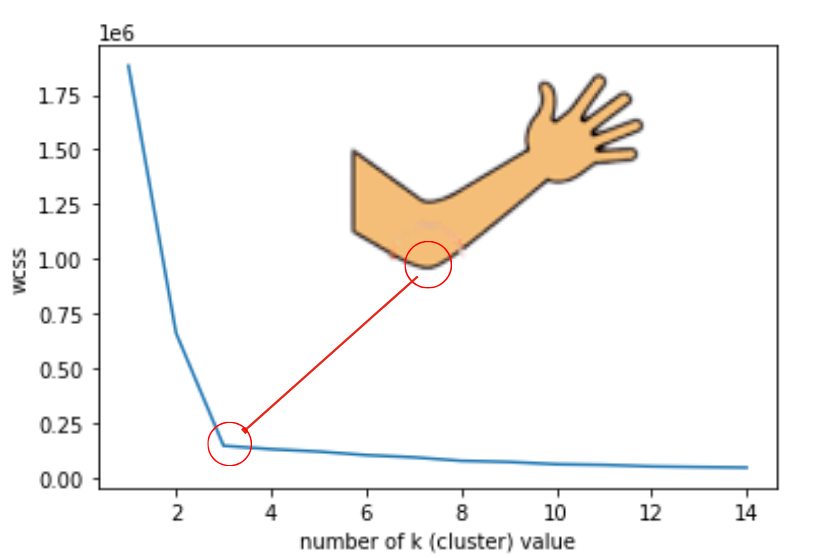

K-means produces an **inertia** measure, representing within-cluster variation.

**Inertia** is how much total distance do observations have from the center (centroid) of their assigned cluster!

As K increases, within-cluster variation generally decreases. The elbow approach looks for a point after which increasing K provides less additional improvement.

### Silhouette score

The silhouette score provides another way to assess how well observations fit their assigned clusters relative to other clusters.

A larger average silhouette score indicates stronger separation/cohesion according to this measure.

### Substantive interpretability

Even if a statistical criterion suggests a particular K, ask:

> Does this solution produce profiles that are interpretable and useful for the question being studied?

The tutorial explicitly asks students to consider this.

## 8. What cluster analysis does NOT do

This is one of the most important parts of the lecture.

Cluster analysis does **not**:

- prove that natural groups objectively exist;
- explain why groups differ;
- establish causal effects;
- automatically create meaningful labels;
- guarantee identical clusters under different methods or variables.

Results may change when we alter:

- the included variables;
- standardization;
- the distance measure;
- the algorithm;
- random starting values;
- the number of clusters.

### The key interpretation rule

A cluster is a **descriptive grouping produced under a particular analytical setup**.

It should not automatically be interpreted as a naturally existing, objectively correct category.

## 9. Cluster labels are arbitrary

Suppose K-means produces:

- Cluster 0
- Cluster 1
- Cluster 2

The numbers are simply **identifiers**.

**Cluster 0 is not automatically safer, weaker, better, lower, or worse than Cluster 1.**

We must examine the cluster profiles first.

For example, after looking at the variables, we might describe a group as:

> “high-leverage, low-profitability firms”

rather than:

> “bad firms”

The label should be based on the observed characteristics of the cluster.

# Part B — Statistics and Machine Learning

## 10. Is clustering statistics or machine learning?

This is an area where **statistics and machine learning overlap**.

K-means existed as a statistical method before the modern use of the term *machine learning*. Today, it is commonly taught as an **unsupervised machine-learning method**.

The mathematics does not change. The label depends mainly on the **analytical purpose and workflow**.

### Two perspectives

| Method | Statistical perspective | Machine-learning perspective |
|---|---|---|
| K-means | Exploratory grouping based on distance | Unsupervised clustering algorithm |

The lecture also contrasts common emphases:

**Statistics often emphasizes**
- explanation;
- uncertainty;
- assumptions;
- interpretation.

**Machine learning often emphasizes**
- algorithms;
- pattern discovery;
- prediction;
- validation;
- performance on unseen data.

This is **not a clean separation**. Regression, logistic regression, PCA, and clustering can belong to both traditions.

# Clustering using Polish Companies Dataset

## 11. The applied question

A financial-stability or banking team may need an **exploratory map of firms** before it has a labelled outcome or before it decides what should be predicted.

In this tutorial, we will:

1. group firms using several financial ratios;
2. investigate how many groups are defensible;
3. profile the resulting groups;
4. examine hierarchical clustering as a second view;
5. translate the findings into a cautious briefing.

### Dataset

The tutorial uses an unlabelled dataset containing:

| Column | Interpretation |
|---|---|
| `firm_id` | Identifier only — **never a clustering feature** |
| `X1` | Profitability: net profit / total assets |
| `X2` | Leverage: total liabilities / total assets |
| `X3` | Working capital / total assets |
| `X4` | Current assets / short-term liabilities |
| `X9` | Asset turnover: sales / total assets |
| `X29` | Logarithm of total assets; a size-related indicator |

There is **NO outcome label**, we are performing an exploratory grouping exercise, not predicting bankruptcy outcomes.

## 12. Before we start:

write your answer before running the next cells:

1. What is the unit of observation?
2. Why is this multivariate data?
3. Why must `firm_id` be excluded from the distance calculation?
4. What is the role of the six financial variables?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

/var/folders/k0/28fxcm8x4c99xqsw2ml0s2hw0000gn/T/ipykernel_32306/1367491319.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [14]:
# Load the tutorial dataset.
# Keep the CSV in the same working directory as this notebook.
df = pd.read_csv("/Users/naeemamr/Downloads/polish_bankruptcy_clustering_unlabelled.csv")
df = df.drop(columns=["class"])
df.columns = ['firm_id'] + [f"X{i}" for i in range(1, len(df.columns))]
df = df.apply(pd.to_numeric, errors='coerce')
display(df.head())
print("Shape:", df.shape)
df.info()

/var/folders/k0/28fxcm8x4c99xqsw2ml0s2hw0000gn/T/ipykernel_32306/4143155064.py:3: DtypeWarning: Columns (1,2,3,6,7,8,10,11,14,15,16,17,18,22,24,25,26,29,34,35,36,38,48,50,51,57,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/naeemamr/Downloads/polish_bankruptcy_clustering_unlabelled.csv")


,firm_id,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X55,X56,X57,X58,X59,X60,X61,X62,X63,X64
0,1,0.159290,0.46240,0.07773,1.1683,-44.853,0.467020,0.189480,0.82895,1.1223,...,90533.0,0.108990,0.41557,0.89101,0.001422,7.7928,4.9914,119.810,3.0465,3.0560
1,2,-0.127430,0.46243,0.26917,1.7517,7.597,0.000925,-0.127430,1.16250,1.2944,...,2624.9,-0.089372,-0.23704,1.06250,0.150410,5.4327,3.4629,100.970,3.6150,3.4725
2,3,0.070488,0.23570,0.52781,3.2393,125.680,0.163670,0.086895,2.87180,1.0574,...,24672.0,0.054286,0.10413,0.94571,0.000000,7.1070,3.3808,76.076,4.7978,4.7818
3,4,0.136760,0.40538,0.31543,1.8705,19.115,0.504970,0.136760,1.45390,1.1144,...,6649.9,0.102630,0.23203,0.89737,0.073024,6.1384,4.2241,88.299,4.1337,4.6484
4,5,-0.110080,0.69793,0.18878,1.2713,-15.344,0.000000,-0.110080,0.43282,1.7350,...,1314.0,0.439880,-0.36440,0.57153,0.000000,18.8010,2.7925,146.390,2.4934,15.0360


Shape: (9792, 65)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9792 entries, 0 to 9791
Data columns (total 65 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   firm_id  9792 non-null   int64  
 1   X1       9791 non-null   float64
 2   X2       9791 non-null   float64
 3   X3       9791 non-null   float64
 4   X4       9749 non-null   float64
 5   X5       9771 non-null   float64
 6   X6       9791 non-null   float64
 7   X7       9791 non-null   float64
 8   X8       9773 non-null   float64
 9   X9       9792 non-null   float64
 10  X10      9791 non-null   float64
 11  X11      9791 non-null   float64
 12  X12      9749 non-null   float64
 13  X13      9771 non-null   float64
 14  X14      9791 non-null   float64
 15  X15      9784 non-null   float64
 16  X16      9773 non-null   float64
 17  X17      9773 non-null   float64
 18  X18      9791 non-null   float64
 19  X19      9771 non-null   float64
 20  X20      9771 non-null   float64
 

## 13. Audit the data

Before clustering, inspect the data.

We want to know:

- what variables are present;
- how many observations there are;
- whether an outcome label exists;
- whether values are missing;
- whether variables have unusual distributions.

**we should not jump directly to K-means!!**

You should be able to understand the missingness and consequences of preprocessing choices rather than automatically deleting rows.

Dropping values should be **justified** and **documented**!

In [15]:
feature_cols = ["X1", "X2", "X3", "X4", "X9", "X29"]

# firm_id is intentionally excluded.
X = df[feature_cols].copy()

print("Clustering features:")
print(feature_cols)

print("\nOutcome / label check:")
print([c for c in df.columns if c not in feature_cols and c != "firm_id"])

Clustering features:
['X1', 'X2', 'X3', 'X4', 'X9', 'X29']

Outcome / label check:
['X5', 'X6', 'X7', 'X8', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28', 'X30', 'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X38', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X46', 'X47', 'X48', 'X49', 'X50', 'X51', 'X52', 'X53', 'X54', 'X55', 'X56', 'X57', 'X58', 'X59', 'X60', 'X61', 'X62', 'X63', 'X64']


In [16]:
audit = pd.DataFrame({
    "missing_n": X.isna().sum(),
    "missing_pct": 100 * X.isna().mean(),
    "mean": X.mean(),
    "median": X.median(),
    "std": X.std()
})

display(audit.round(3))
display(X.describe(percentiles=[.01, .25, .50, .75, .99]).T)

,missing_n,missing_pct,mean,median,std
X1,1,0.010,0.043,0.041,0.359
X2,1,0.010,0.596,0.468,4.587
X3,1,0.010,0.131,0.199,4.559
X4,43,0.439,8.137,1.592,290.647
X9,0,0.000,1.882,1.161,17.675
X29,1,0.010,3.946,3.976,0.866


,count,mean,std,min,1%,25%,50%,75%,99%,max
X1,9791.0,0.043019,0.359321,-12.458000,-0.599170,0.001321,0.041364,0.111130,0.560280,20.4820
X2,9791.0,0.596404,4.587122,0.000000,0.015426,0.263145,0.467740,0.689255,2.478840,446.9100
X3,9791.0,0.130959,4.559074,-445.910000,-1.286370,0.020377,0.199290,0.410670,0.916680,22.7690
X4,9749.0,8.136600,290.647281,-0.045319,0.146470,1.047000,1.591800,2.880400,44.161200,27146.0000
X9,9792.0,1.882296,17.674650,-0.032371,0.054714,1.006675,1.161300,1.970225,7.149459,1704.8000
X29,9791.0,3.946479,0.865714,-0.440090,1.840240,3.398450,3.976400,4.498550,6.011550,9.6518


### Data Distributions

Financial ratios can be skewed and can contain extreme values.

Look at the audit table and identify **at least two features for which the mean and median differ substantially**.

A substantial mean–median difference can be a warning sign that a variable is skewed or affected by extreme observations.

**Do not automatically delete observations.**

Instead ask:

- How much missingness is there?
- Which variables are affected?
- Are extreme values plausible?
- What consequence would deleting observations have?
- What preprocessing choice is justified for this analysis?

### Handling Extreme Values

X4 and X9 stand out because their means are substantially higher than their medians, while their maximum values are extremely large compared with the rest of their distributions. This suggests strong right skewness and the presence of extreme observations. Missingness is very low overall, with X4 having the highest missingness at only 0.44%.

We will not automatically delete these observations. Instead, because K-means is distance-based, extreme values could have a disproportionate influence on the cluster centers and distance calculations. We will therefore **cap extreme values** before clustering. Capping reduces the influence of extreme observations while retaining the firms in the analysis.

For each variable, values below the **1st percentile** will be replaced by the 1st percentile, and values above the **99th percentile** will be replaced by the 99th percentile. After capping, the features will be standardized before applying K-means.

In [17]:
imputer = SimpleImputer(strategy="median")

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=feature_cols,
    index=X.index
)

# Apply the capping rule
lower = X_imputed.quantile(0.01)
upper = X_imputed.quantile(0.99)

X_cap = X_imputed.clip(lower=lower, upper=upper, axis=1)

display(X_cap.describe().T.round(3))
print("Remaining missing values:", int(X_cap.isna().sum().sum()))

,count,mean,std,min,25%,50%,75%,max
X1,9792.0,0.046,0.159,-0.599,0.001,0.041,0.111,0.560
X2,9792.0,0.520,0.382,0.015,0.263,0.468,0.689,2.479
X3,9792.0,0.195,0.351,-1.286,0.020,0.199,0.411,0.917
X4,9792.0,3.160,5.682,0.147,1.048,1.592,2.874,44.049
X9,9792.0,1.626,1.173,0.055,1.007,1.161,1.970,7.149
X29,9792.0,3.948,0.844,1.840,3.398,3.976,4.498,6.012


Remaining missing values: 0


## 15. Standardize the features

K-means uses distances.

A feature with a larger numerical scale can dominate those distances even if it is not substantively more important.

We therefore standardize the selected features before clustering.

In [18]:
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_cap),
    columns=feature_cols,
    index=df.index
)

check = pd.DataFrame({
    "mean": X_scaled.mean(),
    "std": X_scaled.std(ddof=0)
})

display(check.round(3))

,mean,std
X1,-0.0,1.0
X2,0.0,1.0
X3,0.0,1.0
X4,-0.0,1.0
X9,0.0,1.0
X29,0.0,1.0


### What should you see?

The standardized variables should have means close to **0** and standard deviations close to **1**.

This is the practical check that the standardization step worked.

**Important**: standardization changes the **scale**, not the substantive identity of the variables.

# Part D — Choosing K

## 16. Compare candidate values of K

We'll compare:

$$
K = 2,3,4,5,6
$$

using:

1. **inertia / within-cluster sum of squares**;
2. **average silhouette score**.

It's completely normal for the two criterias to disagree. That is not an error. It is part of the analytical decision.

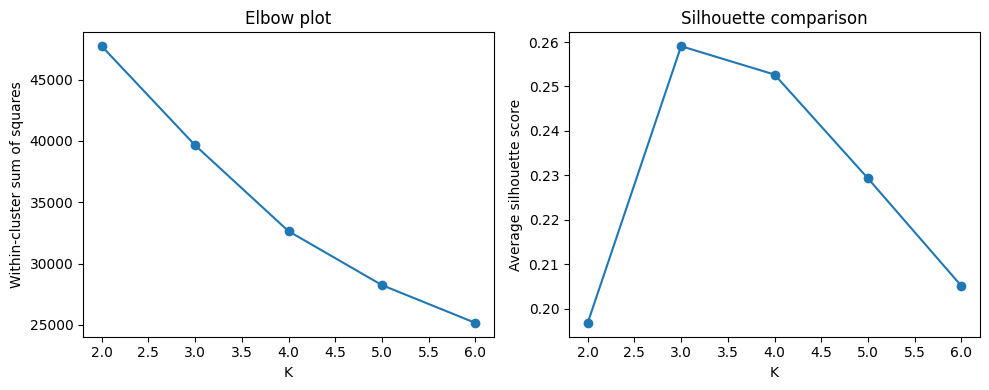

In [19]:
ks = range(2, 7)
inertia, silhouettes = [], []

for k in ks:
    model = KMeans(
        n_clusters=k,
        random_state=405,
        n_init=20
    )
    labels = model.fit_predict(X_scaled)

    inertia.append(model.inertia_)
    silhouettes.append(
        silhouette_score(
            X_scaled,
            labels,
            sample_size=min(2000, len(X_scaled)),
            random_state=405
        )
    )

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(list(ks), inertia, marker="o")
axes[0].set(
    xlabel="K",
    ylabel="Within-cluster sum of squares",
    title="Elbow plot"
)

axes[1].plot(list(ks), silhouettes, marker="o")
axes[1].set(
    xlabel="K",
    ylabel="Average silhouette score",
    title="Silhouette comparison"
)

plt.tight_layout()
plt.show()

## 17. Decision checkpoint: choose K

Look at both plots.

### Ask three questions

**1. Where is the elbow?**

Identify the point after which increasing K produces diminishing improvement in within-cluster variation.

**2. Which K has the largest silhouette score?**

The maximum silhouette score is one piece of evidence about cluster separation/cohesion.

**3. Which solution gives interpretable firm profiles?**

A statistically attractive solution is not automatically the most useful substantive solution.

### Write your decision before fitting the final model

> I choose K = ___ because the elbow occurs around ___, the silhouette evidence is ___, and the resulting profiles appear ___.

If the criteria disagree, **state which evidence you prioritize and why**.

In [20]:
# After documenting your reasoning above, enter the chosen K.
chosen_k = 3  # <-- CHANGE THIS after examining your plots

final_model = KMeans(
    n_clusters=chosen_k,
    random_state=405,
    n_init=20
)

cluster_id = final_model.fit_predict(X_scaled)

# Part E — Fit and Profile the Selected K-means Solution

## 18. Attach cluster IDs to the firms

We now assign every firm to one of the selected clusters.

In [21]:
results = df[["firm_id"]].copy()
results["cluster"] = cluster_id

display(results["cluster"].value_counts().sort_index())

cluster
0    6016
1    2973
2     803
Name: count, dtype: int64

## 19. Never rank the cluster numbers

Do **not** interpret:

- Cluster 0 as “best”
- Cluster 1 as “medium”
- Cluster 2 as “worst”

The cluster numbers are arbitrary identifiers.

We need to inspect the characteristics of each cluster before giving it a descriptive name.

In [22]:
profile_z = (
    X_scaled.assign(cluster=cluster_id)
    .groupby("cluster")
    .mean()
)

profile_raw = (
    X_cap.assign(cluster=cluster_id)
    .groupby("cluster")
    .mean()
)

print("Standardized cluster profiles:")
display(profile_z.round(2))

print("Raw-scale cluster profiles:")
display(profile_raw.round(2))

Standardized cluster profiles:


,X1,X2,X3,X4,X9,X29
cluster,,,,,,
0,-0.05,-0.02,-0.17,-0.24,-0.34,0.47
1,0.53,-0.53,0.84,0.61,0.55,-0.69
2,-1.59,2.12,-1.80,-0.42,0.53,-0.97


Raw-scale cluster profiles:


,X1,X2,X3,X4,X9,X29
cluster,,,,,,
0,0.04,0.51,0.13,1.77,1.22,4.34
1,0.13,0.32,0.49,6.61,2.27,3.36
2,-0.21,1.33,-0.44,0.78,2.25,3.13


## 20. How to interpret the standardized profile

The standardized profile is especially useful because:

- `0` is approximately the overall sample mean;
- positive values indicate the cluster is above the sample mean;
- negative values indicate the cluster is below the sample mean;
- the magnitude indicates how far the cluster mean is from the overall mean in standard-deviation units.

### Required profile interpretation

For **every cluster**:

1. Identify at least **two ratios clearly above or below** the sample mean.
2. Give the cluster a short descriptive name based on the evidence.
3. Avoid labels such as **“good,” “bad,” “safe,” or “bankrupt.”**
4. Report the **number and percentage of firms** in the cluster.
5. Explain why the profile is **descriptive**, not a causal or predictive conclusion.

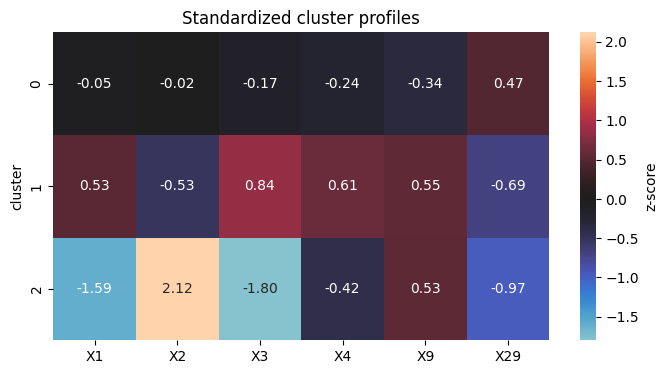

In [23]:
# Standardized cluster profile heatmap
plt.figure(figsize=(8, 4))

sns.heatmap(
    profile_z,
    annot=True,
    fmt=".2f",
    center=0,
    cbar_kws={"label": "z-score"}
)

plt.title("Standardized cluster profiles")
plt.show()

### Example of appropriate interpretation language

Instead of:

> “Cluster 1 is the safest firms.”

write:

> “Cluster 1 is characterized by relatively high profitability and working capital, alongside lower leverage than the sample average.”

Instead of:

> “Cluster 2 contains bankrupt firms.”

write:

> “Cluster 2 is characterized by relatively high leverage and lower profitability.”

The second forms describe **observed characteristics** without claiming causality or treating the clusters as bankruptcy outcomes.

In [ ]:
# Cluster size: count and percentage
cluster_sizes = results["cluster"].value_counts().sort_index().rename("n").to_frame()
cluster_sizes["pct"] = 100 * cluster_sizes["n"] / len(results)

display(cluster_sizes.round(2))

### Cluster Profile Interpretation

Looking at the standardized and raw-scale profiles, the clusters show distinct combinations of financial characteristics.

- **Cluster 0 — Moderate / Relatively Larger Firms:** This cluster is broadly close to the overall sample mean across most financial ratios. Its most noticeable characteristic is relatively higher firm size (X29), while most other ratios are only slightly below the sample mean.

- **Cluster 1 — Higher-Profitability and Liquidity Firms:** These firms have above-average profitability (X1), working capital (X3), current ratio (X4), and asset turnover (X9), combined with below-average leverage (X2). They are also relatively smaller in size (X29).

- **Cluster 2 — Highly Leveraged, Low-Profitability Firms:** These firms have substantially below-average profitability (X1) and working capital (X3), while leverage (X2) is considerably above the sample mean. They are also relatively smaller in size (X29), with somewhat above-average asset turnover (X9).

An interesting contrast is between **Clusters 1 and 2**: both are relatively small firms, but their financial profiles differ considerably. Cluster 1 combines lower leverage with stronger profitability and liquidity, whereas Cluster 2 combines very high leverage with substantially lower profitability and working capital.

These descriptions are **descriptive rather than causal or predictive**. The clustering algorithm identifies firms with similar observed financial characteristics; it does not establish why these characteristics occur, whether one variable causes another, or whether firms in a particular cluster will experience bankruptcy.

**Cluster sizes should also be reported using the cluster-count table above, including both the number and percentage of firms in each cluster.**

## 21. A two-feature view

For a simpler illustration we will visualize the K-means solution using:

- `X1` — profitability
- `X2` — leverage

This is useful for visual intuition, but remember:

> The clusters were formed using **six variables**, so a two-dimensional plot is only a partial view.

Apparent overlap in this plot does not prove that the six-dimensional profiles are identical.

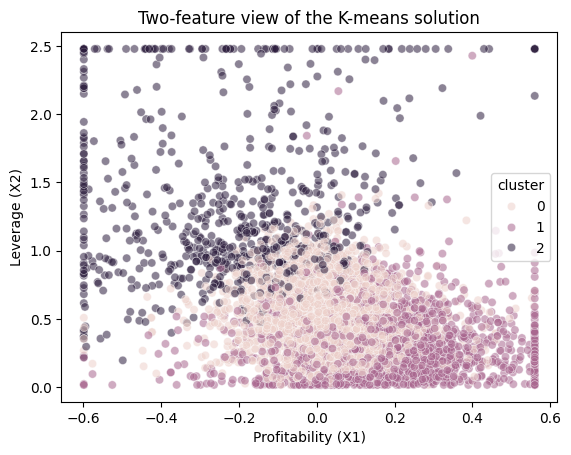

In [24]:
plot_df = X_cap.assign(cluster=cluster_id)

sns.scatterplot(
    data=plot_df,
    x="X1",
    y="X2",
    hue="cluster",
    alpha=.55
)

plt.xlabel("Profitability (X1)")
plt.ylabel("Leverage (X2)")
plt.title("Two-feature view of the K-means solution")
plt.show()

# Part F — Hierarchical Clustering as a Second View

## 22. Why use a sample for the dendrogram?

A dendrogram can become unreadable when there are thousands of firms.

Accordingly we will take a **reproducible sample of up to 80 firms** and demonstrates how agglomerative hierarchical clustering joins similar observations.

This is a **supporting view**, not a replacement for the full K-means analysis.

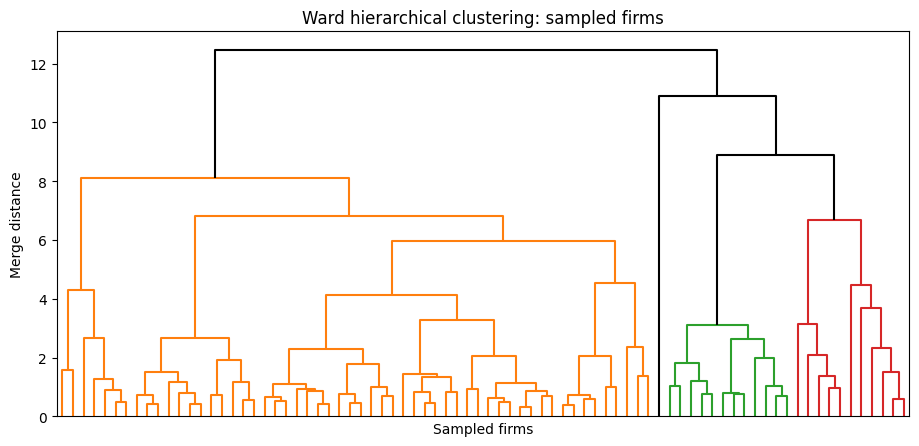

In [25]:
sample = X_scaled.sample(
    n=min(80, len(X_scaled)),
    random_state=405
)

Z = linkage(sample, method="ward")

plt.figure(figsize=(11, 5))

dendrogram(
    Z,
    no_labels=True,
    color_threshold=None,
    above_threshold_color="black"
)

plt.xlabel("Sampled firms")
plt.ylabel("Merge distance")
plt.title("Ward hierarchical clustering: sampled firms")
plt.show()

## 23. Interpret the dendrogram

Look at the heights where the largest merges occur.

Ask:

1. At which heights do the largest merges occur?
2. Where could you draw a horizontal cut?
3. How many broad groups would that cut suggest?
4. Does the picture broadly support your K-means choice?

### Important limitation

The dendrogram is based on a **sample of firms**, not every firm.

Therefore, it is supporting evidence for the clustering structure, not a final answer for every observation.

# Part G — Communicating the Result

## 24. The 120–150 word policymaker briefing

The tutorial asks for a **120–150 word briefing** for a bank or financial-stability policymaker.

Your briefing must include:

1. **The question**
2. **The data and preprocessing**
3. **Evidence supporting K**
4. **Two or more profile descriptions**
5. **One practical use**
6. **Two limitations**

### Language requirements

Use cautious descriptive language such as:

- **associated with**
- **characterized by**
- **grouped by**

### Avoid

Do not use causal language.

Do not describe the clusters as **bankruptcy outcomes**.

The analysis is an exploratory grouping exercise based on financial characteristics; it does not establish why firms differ or whether a firm will become bankrupt.

## 25. Suggested briefing structure

You can structure the briefing as one short paragraph:

**Sentence 1 — Question:**  
What exploratory question are we asking?

**Sentence 2 — Data/preprocessing:**  
What firms and financial variables were used, and how were missing values / scales handled?

**Sentence 3 — K evidence:**  
What did the elbow, silhouette score, and interpretability suggest?

**Sentences 4–6 — Profiles:**  
Describe at least two clusters using their strongest characteristics.

**Sentence 7 — Practical use:**  
How could a bank or financial-stability team use these descriptive profiles?

**Final sentence(s) — Limitations:**  
Mention at least two limitations, such as dependence on variable choice/preprocessing and the fact that clustering does not establish causality or prediction.

## Write your briefing Here:
*double click to write*